# Model 2: Acoustic → Physiological Features → Stress Level

**Pipeline:**
1. Merge acoustic + physiological features with stress labels
2. **Stage A** — Predict physiological features from acoustic features (regression)
3. **Stage B** — Predict stress level from predicted physiological features (classification)

**Dataset:** StressID — 54 subjects × 7 tasks = 378 samples  
**Target:** `binary-stress` (0/1) and `affect3-class` (0=low, 1=medium, 2=high)

**Interpretable models used:** Ridge Regression (Stage A) + Decision Tree / Logistic Regression (Stage B)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    r2_score, mean_absolute_error,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, f1_score
)

SEED = 42
np.random.seed(SEED)

## 1. Load and Merge Data

In [2]:
# Load features
acoustic = pd.read_csv('data/stressid/features/stressid_features.csv')
physio   = pd.read_csv('data/stressid/features/stressid_physio_features.csv')
labels   = pd.read_csv('data/StressID Dataset/labels.csv')

# Prefix physio feature columns to avoid name collisions with acoustic on merge
PHYSIO_COLS_ORIG = [c for c in physio.columns if c not in ('subject_id', 'task')]
physio = physio.rename(columns={c: f'physio_{c}' for c in PHYSIO_COLS_ORIG})
PHYSIO_COLS = [f'physio_{c}' for c in PHYSIO_COLS_ORIG]

# Parse labels: 'subject/task' → subject_id, task
labels[['subject_id', 'task']] = labels['subject/task'].str.split('_', n=1, expand=True)
labels = labels.drop(columns=['subject/task'])

# Keep only the 7 tasks present in acoustic/physio features
TASKS = {'Counting1', 'Counting2', 'Counting3', 'Math', 'Reading', 'Speaking', 'Stroop'}
labels = labels[labels['task'].isin(TASKS)]

# Merge: acoustic ∩ physio (inner), then left-join labels
df = (
    acoustic
    .merge(physio, on=['subject_id', 'task'], how='inner')
    .merge(labels, on=['subject_id', 'task'], how='left')
)

print(f'Merged dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Subjects: {df["subject_id"].nunique()}, Tasks: {df["task"].nunique()}')
print(f'\nLabel distribution:')
print(df['binary-stress'].value_counts().rename({0: 'No stress', 1: 'Stress'}))
print()
print(df['affect3-class'].value_counts().rename({0: 'Low', 1: 'Medium', 2: 'High'}))

Merged dataset: 378 rows × 120 columns
Subjects: 54, Tasks: 7

Label distribution:
binary-stress
Stress       268
No stress    110
Name: count, dtype: int64

affect3-class
High      190
Medium    124
Low        64
Name: count, dtype: int64


In [3]:
# Define feature groups
ACOUSTIC_COLS = [c for c in acoustic.columns if c not in ('subject_id', 'task')]
PHYSIO_COLS   = [c for c in physio.columns   if c not in ('subject_id', 'task')]

# Drop rows with missing labels
df = df.dropna(subset=['binary-stress', 'affect3-class'])

print(f'After dropping unlabelled rows: {len(df)} samples')
print(f'Acoustic features: {len(ACOUSTIC_COLS)}')
print(f'Physiological features: {len(PHYSIO_COLS)}')

After dropping unlabelled rows: 378 samples
Acoustic features: 91
Physiological features: 25


## 2. Cross-Validation Strategy

We use **GroupKFold** with `subject_id` as the group variable.  
This ensures no subject appears in both train and test — preventing data leakage across the repeated-measures structure.

In [4]:
groups = df['subject_id'].values
gkf = GroupKFold(n_splits=5)

# Encode task as a categorical feature (one-hot)
task_dummies = pd.get_dummies(df['task'], prefix='task')

X_acoustic = pd.concat([df[ACOUSTIC_COLS].reset_index(drop=True),
                         task_dummies.reset_index(drop=True)], axis=1).values

y_binary  = df['binary-stress'].values.astype(int)
y_affect3 = df['affect3-class'].values.astype(int)

print(f'X_acoustic shape: {X_acoustic.shape}')
print(f'y_binary  shape: {y_binary.shape}')
print(f'y_affect3 shape: {y_affect3.shape}')

X_acoustic shape: (378, 98)
y_binary  shape: (378,)
y_affect3 shape: (378,)


## 3. Stage A — Predict Physiological Features from Acoustic Features

Fit one **Ridge Regression** model per physiological target.  
Ridge is interpretable (linear coefficients) and handles the high-dimensional acoustic feature space well.

In [5]:
# Stage A: acoustic → physio (multi-output regression)
Y_physio_raw = df[PHYSIO_COLS].values

# Drop columns that are entirely NaN (e.g. rr_variability — bandpass failed on raw ADC)
valid_mask = ~np.all(np.isnan(Y_physio_raw), axis=0)
PHYSIO_COLS_VALID = [c for c, v in zip(PHYSIO_COLS, valid_mask) if v]
Y_physio_raw = Y_physio_raw[:, valid_mask]
print(f'Dropped all-NaN physio columns: {[c for c, v in zip(PHYSIO_COLS, valid_mask) if not v]}')
print(f'Remaining physio targets: {len(PHYSIO_COLS_VALID)}')

# Impute remaining NaNs (partial NaN columns)
target_imputer = SimpleImputer(strategy='median')
Y_physio = target_imputer.fit_transform(Y_physio_raw)

# Pipeline: impute X → scale X → Ridge
stage_a_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   Ridge(alpha=1.0))
])

# Cross-validated predictions of physio features
Y_physio_pred = np.zeros_like(Y_physio, dtype=float)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_acoustic, Y_physio, groups)):
    stage_a_pipe.fit(X_acoustic[train_idx], Y_physio[train_idx])
    Y_physio_pred[test_idx] = stage_a_pipe.predict(X_acoustic[test_idx])

# Report per-physio-feature R² and MAE
stageA_results = []
for i, col in enumerate(PHYSIO_COLS_VALID):
    r2  = r2_score(Y_physio[:, i], Y_physio_pred[:, i])
    mae = mean_absolute_error(Y_physio[:, i], Y_physio_pred[:, i])
    stageA_results.append({'feature': col, 'R2': round(r2, 3), 'MAE': round(mae, 3)})

stageA_df = pd.DataFrame(stageA_results).sort_values('R2', ascending=False)
print('\nStage A — Acoustic → Physio (Ridge Regression, 5-fold GroupKFold):')
print(stageA_df.to_string(index=False))

Dropped all-NaN physio columns: ['physio_rr_variability']
Remaining physio targets: 24

Stage A — Acoustic → Physio (Ridge Regression, 5-fold GroupKFold):
                  feature     R2       MAE
     physio_rr_peak_count  1.000     0.000
  physio_rr_resp_rate_bpm  1.000     0.000
         physio_ecg_rmssd -0.618    69.203
     physio_ecg_rr_std_ms -0.763    56.609
          physio_ecg_sdnn -0.763    56.609
         physio_ecg_pnn50 -0.778     0.195
physio_eda_scr_peak_count -0.939     4.025
 physio_eda_scr_peak_rate -0.939     0.067
         physio_eda_slope -1.049   125.460
           physio_eda_min -1.185 12178.473
    physio_ecg_rr_mean_ms -1.209   104.371
    physio_ecg_peak_count -1.365    13.516
       physio_ecg_hr_mean -1.375    13.539
           physio_eda_std -1.483  2307.300
      physio_eda_scl_mean -1.492 14280.805
          physio_eda_mean -1.504 14245.495
       physio_eda_scl_std -1.528  2182.565
           physio_eda_max -1.632 17049.754
       physio_eda_scr_std -1

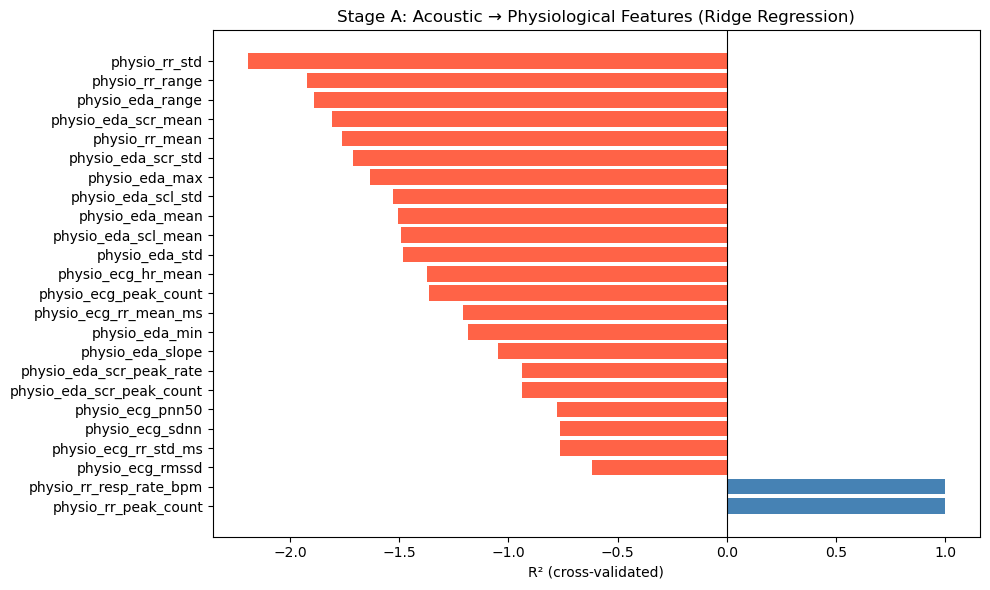

In [6]:
# Visualise Stage A R² scores
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if r >= 0 else 'tomato' for r in stageA_df['R2']]
ax.barh(stageA_df['feature'], stageA_df['R2'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('R² (cross-validated)')
ax.set_title('Stage A: Acoustic → Physiological Features (Ridge Regression)')
plt.tight_layout()
plt.savefig('stageA_r2_scores.png', dpi=150)
plt.show()

## 4. Stage B — Predict Stress Level from Physiological Features

We run Stage B **three ways** to evaluate interpretability vs. performance trade-off:
- **4a** — from *true* physio features (upper bound / oracle)
- **4b** — from *predicted* physio features (Stage A → Stage B pipeline)
- **4c** — directly from acoustic features (baseline comparison)

In [7]:
def evaluate_classifier(X, y, groups, label_name, model_name, model, feature_names=None):
    """GroupKFold cross-validated evaluation of a classifier."""
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf',     model)
    ])
    y_pred = cross_val_predict(pipe, X, y, cv=gkf, groups=groups)
    f1  = f1_score(y, y_pred, average='weighted')
    acc = np.mean(y == y_pred)

    print(f'\n─── {model_name} | target: {label_name} ───')
    print(f'  Accuracy: {acc:.3f}  |  Weighted F1: {f1:.3f}')
    print(classification_report(y, y_pred))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(y, y_pred, ax=axes[0])
    axes[0].set_title(f'{model_name} — {label_name}\nConfusion Matrix')

    # Feature importance (if available)
    pipe.fit(X, y)
    clf = pipe.named_steps['clf']
    names = feature_names if feature_names is not None else [f'feat_{i}' for i in range(X.shape[1])]

    if hasattr(clf, 'feature_importances_'):
        imp = clf.feature_importances_
        top_n = min(15, len(imp))
        top_idx = np.argsort(imp)[-top_n:]
        axes[1].barh(range(top_n), imp[top_idx], color='steelblue')
        axes[1].set_yticks(range(top_n))
        axes[1].set_yticklabels([names[i] for i in top_idx], fontsize=8)
        axes[1].set_title('Top Feature Importances')
    elif hasattr(clf, 'coef_'):
        coef = np.abs(clf.coef_).mean(axis=0) if clf.coef_.ndim > 1 else np.abs(clf.coef_)
        top_n = min(15, len(coef))
        top_idx = np.argsort(coef)[-top_n:]
        axes[1].barh(range(top_n), coef[top_idx], color='steelblue')
        axes[1].set_yticks(range(top_n))
        axes[1].set_yticklabels([names[i] for i in top_idx], fontsize=8)
        axes[1].set_title('Top |Coefficient| Values')
    else:
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    return {'model': model_name, 'target': label_name, 'accuracy': acc, 'f1_weighted': f1}


In [8]:
# Y_physio and Y_physio_pred are already imputed — use directly
X_physio_true = Y_physio
X_physio_pred = Y_physio_pred

# Build feature name lists for interpretability plots
acoustic_feature_names = list(ACOUSTIC_COLS) + list(pd.get_dummies(df['task'], prefix='task').columns)

models = {
    'DecisionTree (max_depth=4)': DecisionTreeClassifier(max_depth=4, random_state=SEED),
    'LogisticRegression':         LogisticRegression(max_iter=1000, random_state=SEED),
    'RandomForest':               RandomForestClassifier(n_estimators=100, random_state=SEED),
}

results = []

### 4a — Oracle: True Physiological Features → Stress


─── Oracle | DecisionTree (max_depth=4) | target: binary-stress ───
  Accuracy: 0.598  |  Weighted F1: 0.580
              precision    recall  f1-score   support

           0       0.25      0.19      0.22       110
           1       0.70      0.76      0.73       268

    accuracy                           0.60       378
   macro avg       0.47      0.48      0.47       378
weighted avg       0.57      0.60      0.58       378



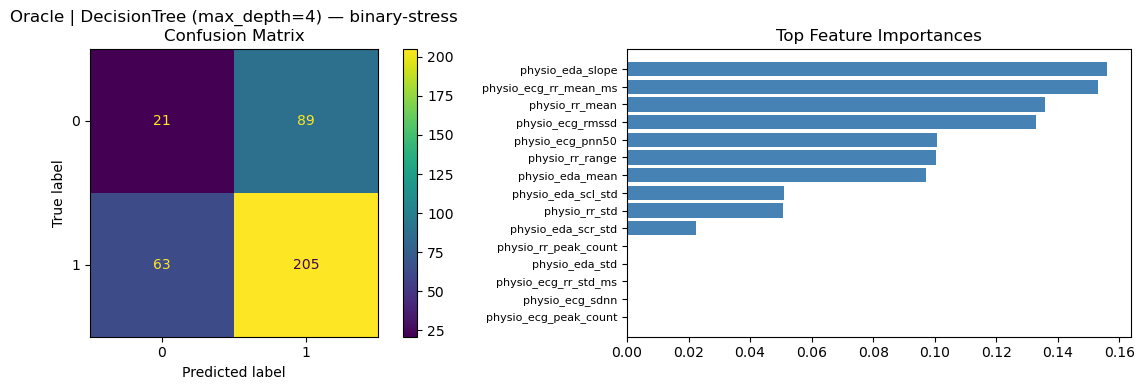


─── Oracle | DecisionTree (max_depth=4) | target: affect3-class ───
  Accuracy: 0.294  |  Weighted F1: 0.296
              precision    recall  f1-score   support

           0       0.10      0.09      0.09        64
           1       0.27      0.36      0.31       124
           2       0.41      0.32      0.36       190

    accuracy                           0.29       378
   macro avg       0.26      0.26      0.25       378
weighted avg       0.31      0.29      0.30       378



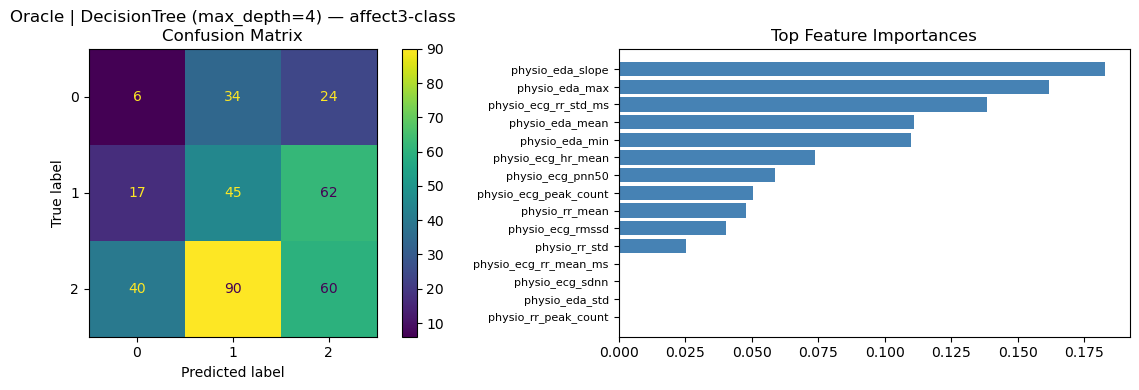


─── Oracle | LogisticRegression | target: binary-stress ───
  Accuracy: 0.664  |  Weighted F1: 0.581
              precision    recall  f1-score   support

           0       0.16      0.04      0.06       110
           1       0.70      0.92      0.80       268

    accuracy                           0.66       378
   macro avg       0.43      0.48      0.43       378
weighted avg       0.54      0.66      0.58       378



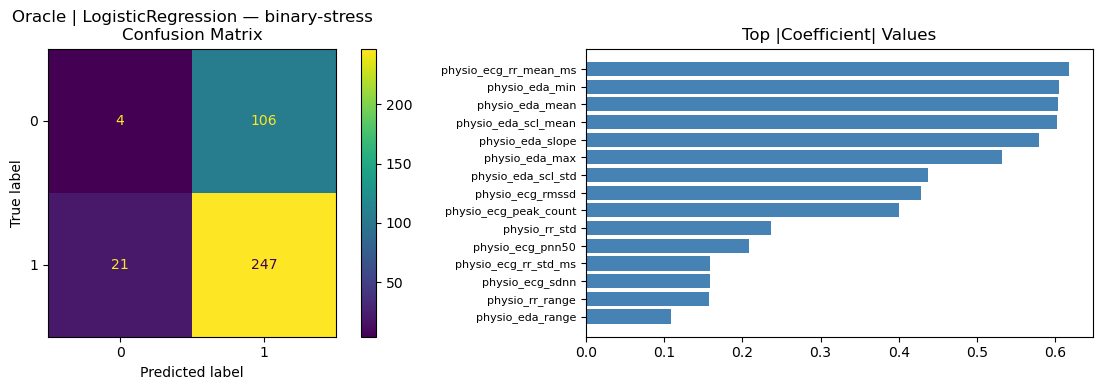


─── Oracle | LogisticRegression | target: affect3-class ───
  Accuracy: 0.392  |  Weighted F1: 0.352
              precision    recall  f1-score   support

           0       0.06      0.02      0.03        64
           1       0.27      0.23      0.25       124
           2       0.46      0.63      0.53       190

    accuracy                           0.39       378
   macro avg       0.26      0.29      0.27       378
weighted avg       0.33      0.39      0.35       378



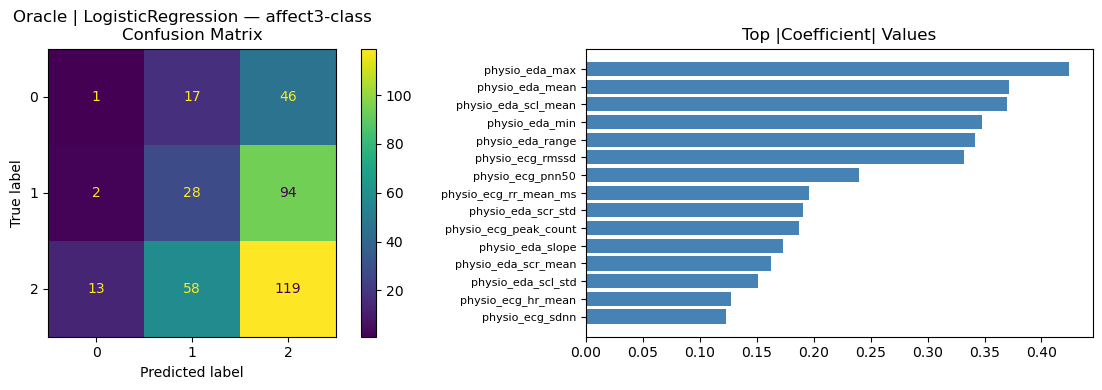


─── Oracle | RandomForest | target: binary-stress ───
  Accuracy: 0.632  |  Weighted F1: 0.578
              precision    recall  f1-score   support

           0       0.19      0.08      0.11       110
           1       0.69      0.86      0.77       268

    accuracy                           0.63       378
   macro avg       0.44      0.47      0.44       378
weighted avg       0.55      0.63      0.58       378



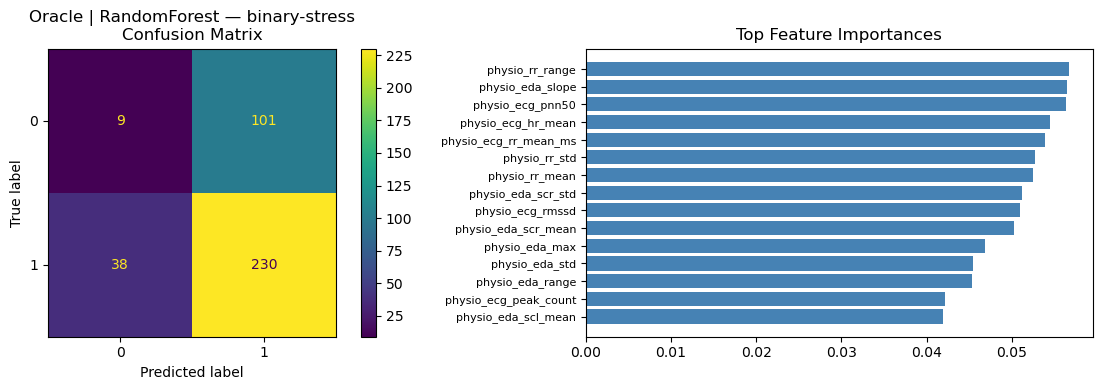


─── Oracle | RandomForest | target: affect3-class ───
  Accuracy: 0.418  |  Weighted F1: 0.387
              precision    recall  f1-score   support

           0       0.08      0.03      0.04        64
           1       0.33      0.29      0.31       124
           2       0.49      0.63      0.55       190

    accuracy                           0.42       378
   macro avg       0.30      0.32      0.30       378
weighted avg       0.37      0.42      0.39       378



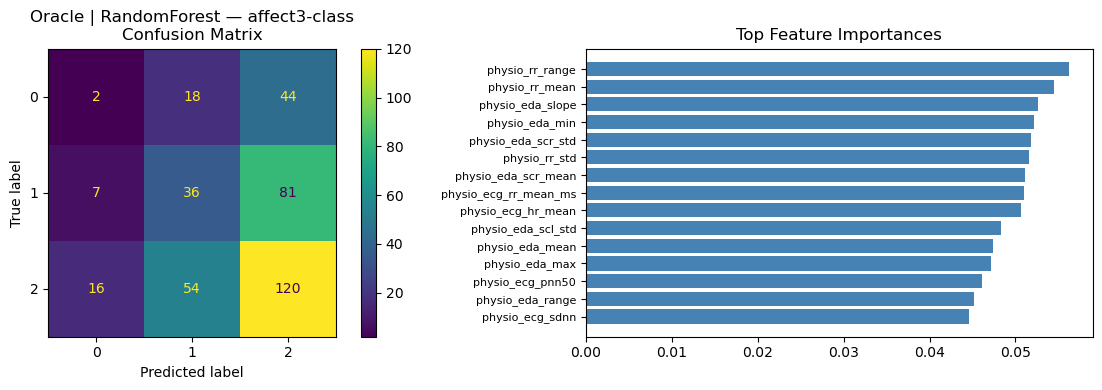

In [9]:
for mname, model in models.items():
    for target, y in [('binary-stress', y_binary), ('affect3-class', y_affect3)]:
        r = evaluate_classifier(X_physio_true, y, groups,
                                label_name=target,
                                model_name=f'Oracle | {mname}',
                                model=model,
                                feature_names=PHYSIO_COLS_VALID)
        r['input'] = 'oracle_physio'
        results.append(r)

### 4b — Pipeline: Acoustic → Predicted Physio → Stress


─── Pipeline | DecisionTree (max_depth=4) | target: binary-stress ───
  Accuracy: 0.603  |  Weighted F1: 0.571
              precision    recall  f1-score   support

           0       0.21      0.13      0.16       110
           1       0.69      0.80      0.74       268

    accuracy                           0.60       378
   macro avg       0.45      0.46      0.45       378
weighted avg       0.55      0.60      0.57       378



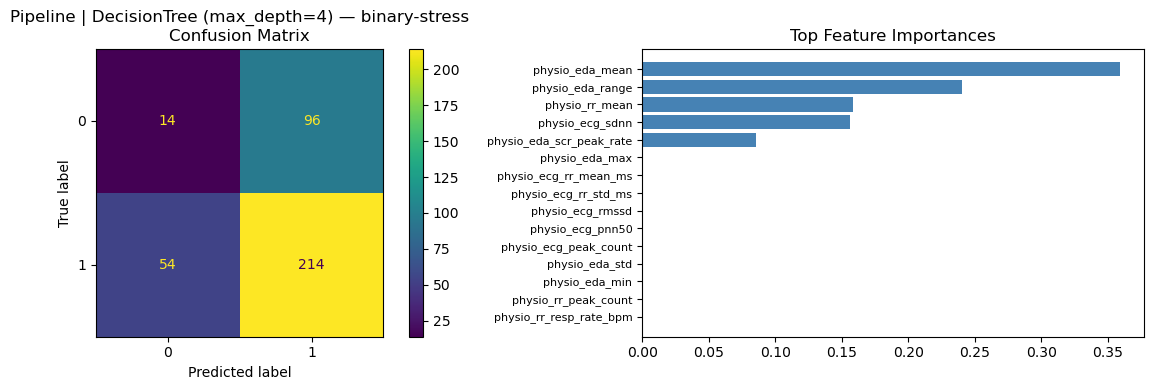


─── Pipeline | DecisionTree (max_depth=4) | target: affect3-class ───
  Accuracy: 0.471  |  Weighted F1: 0.363
              precision    recall  f1-score   support

           0       0.29      0.08      0.12        64
           1       0.22      0.04      0.07       124
           2       0.50      0.88      0.64       190

    accuracy                           0.47       378
   macro avg       0.34      0.33      0.28       378
weighted avg       0.37      0.47      0.36       378



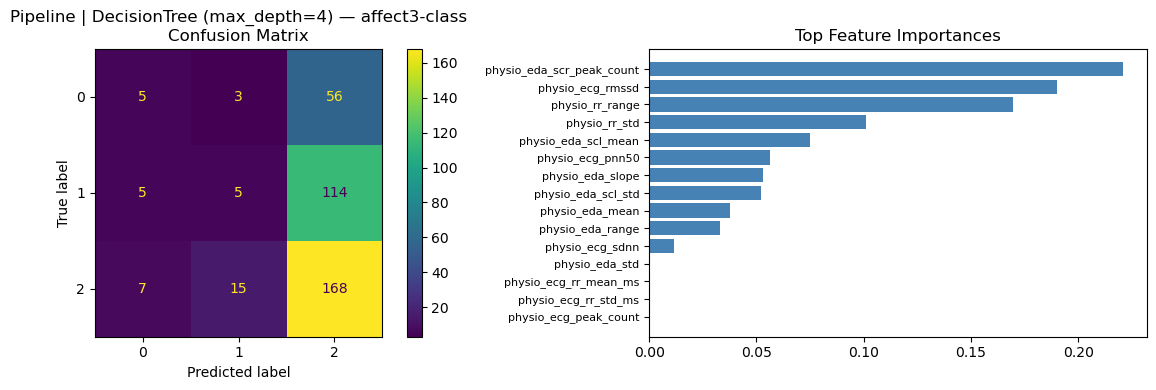


─── Pipeline | LogisticRegression | target: binary-stress ───
  Accuracy: 0.677  |  Weighted F1: 0.592
              precision    recall  f1-score   support

           0       0.23      0.05      0.08       110
           1       0.71      0.94      0.80       268

    accuracy                           0.68       378
   macro avg       0.47      0.49      0.44       378
weighted avg       0.57      0.68      0.59       378



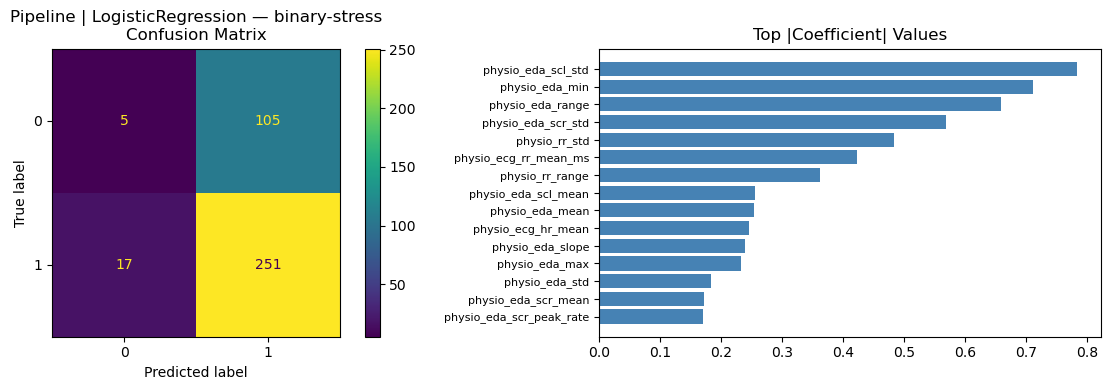


─── Pipeline | LogisticRegression | target: affect3-class ───
  Accuracy: 0.437  |  Weighted F1: 0.384
              precision    recall  f1-score   support

           0       0.27      0.06      0.10        64
           1       0.27      0.18      0.21       124
           2       0.50      0.73      0.59       190

    accuracy                           0.44       378
   macro avg       0.34      0.32      0.30       378
weighted avg       0.38      0.44      0.38       378



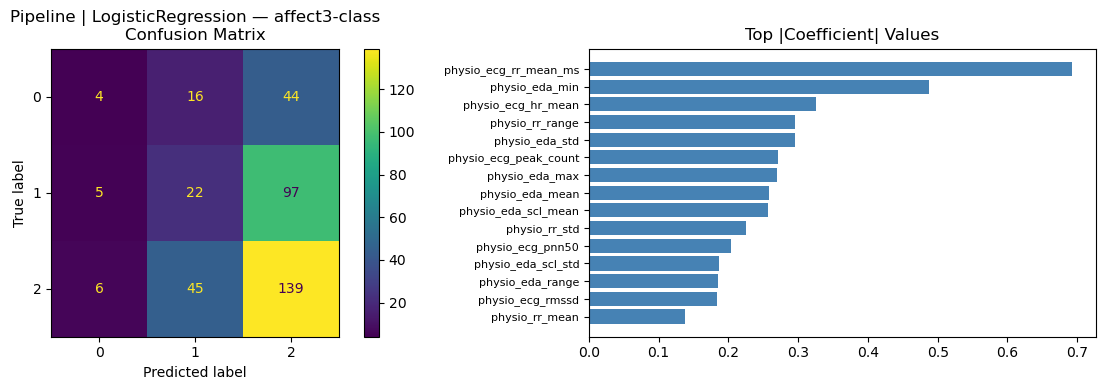


─── Pipeline | RandomForest | target: binary-stress ───
  Accuracy: 0.659  |  Weighted F1: 0.597
              precision    recall  f1-score   support

           0       0.26      0.09      0.13       110
           1       0.71      0.89      0.79       268

    accuracy                           0.66       378
   macro avg       0.48      0.49      0.46       378
weighted avg       0.57      0.66      0.60       378



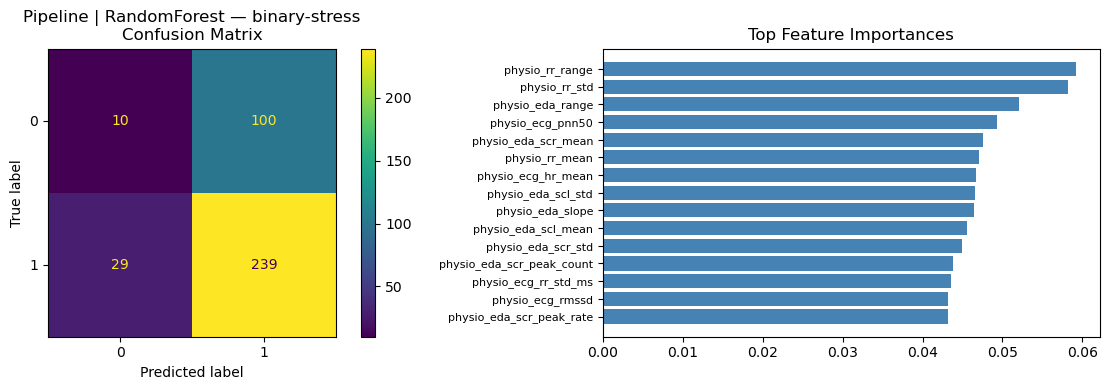


─── Pipeline | RandomForest | target: affect3-class ───
  Accuracy: 0.378  |  Weighted F1: 0.357
              precision    recall  f1-score   support

           0       0.43      0.14      0.21        64
           1       0.21      0.19      0.20       124
           2       0.45      0.58      0.51       190

    accuracy                           0.38       378
   macro avg       0.36      0.30      0.31       378
weighted avg       0.37      0.38      0.36       378



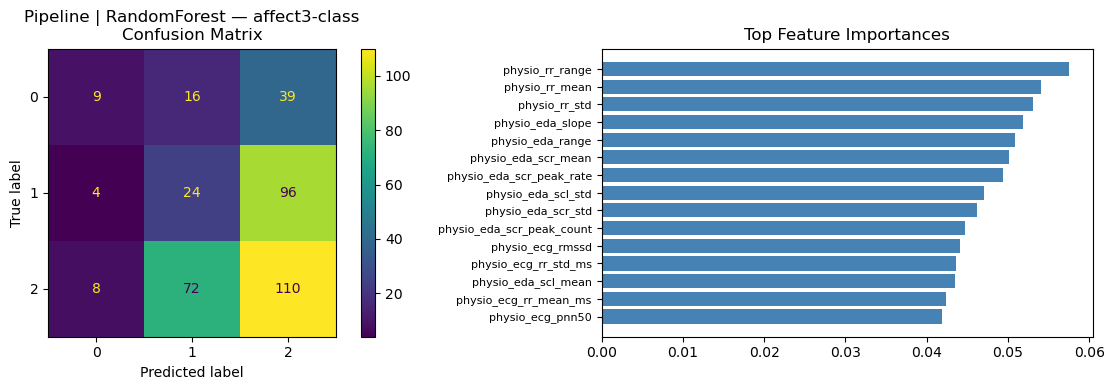

In [10]:
for mname, model in models.items():
    for target, y in [('binary-stress', y_binary), ('affect3-class', y_affect3)]:
        r = evaluate_classifier(X_physio_pred, y, groups,
                                label_name=target,
                                model_name=f'Pipeline | {mname}',
                                model=model,
                                feature_names=PHYSIO_COLS_VALID)
        r['input'] = 'predicted_physio'
        results.append(r)

### 4c — Baseline: Acoustic Features Directly → Stress


─── Baseline | DecisionTree (max_depth=4) | target: binary-stress ───
  Accuracy: 0.622  |  Weighted F1: 0.604
              precision    recall  f1-score   support

           0       0.30      0.23      0.26       110
           1       0.71      0.78      0.75       268

    accuracy                           0.62       378
   macro avg       0.51      0.51      0.50       378
weighted avg       0.59      0.62      0.60       378



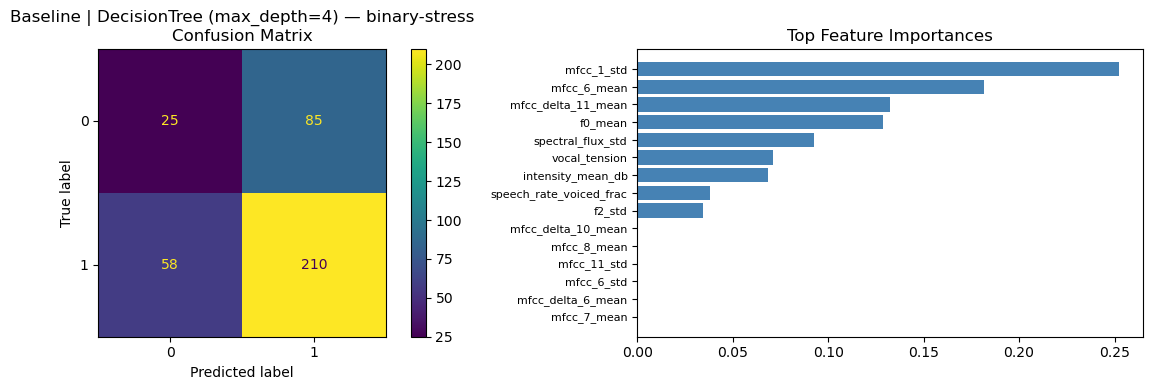


─── Baseline | DecisionTree (max_depth=4) | target: affect3-class ───
  Accuracy: 0.468  |  Weighted F1: 0.441
              precision    recall  f1-score   support

           0       0.31      0.14      0.19        64
           1       0.37      0.30      0.33       124
           2       0.53      0.69      0.60       190

    accuracy                           0.47       378
   macro avg       0.40      0.38      0.37       378
weighted avg       0.44      0.47      0.44       378



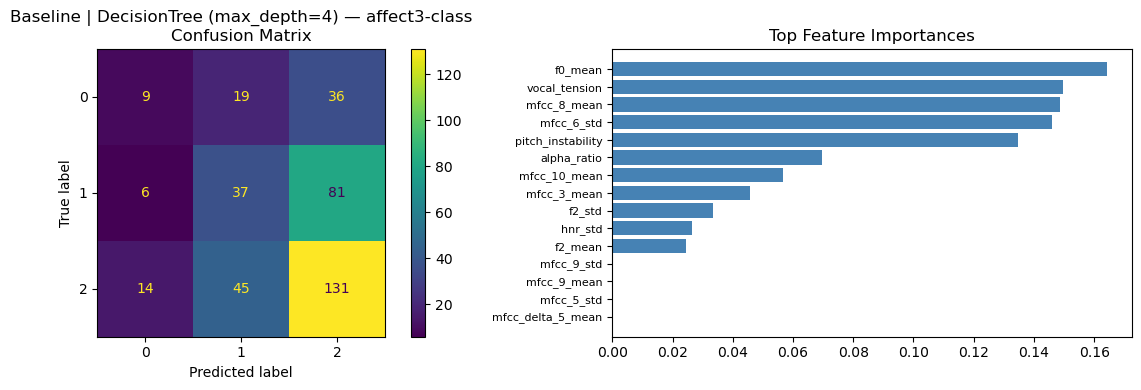


─── Baseline | LogisticRegression | target: binary-stress ───
  Accuracy: 0.624  |  Weighted F1: 0.621
              precision    recall  f1-score   support

           0       0.35      0.33      0.34       110
           1       0.73      0.75      0.74       268

    accuracy                           0.62       378
   macro avg       0.54      0.54      0.54       378
weighted avg       0.62      0.62      0.62       378



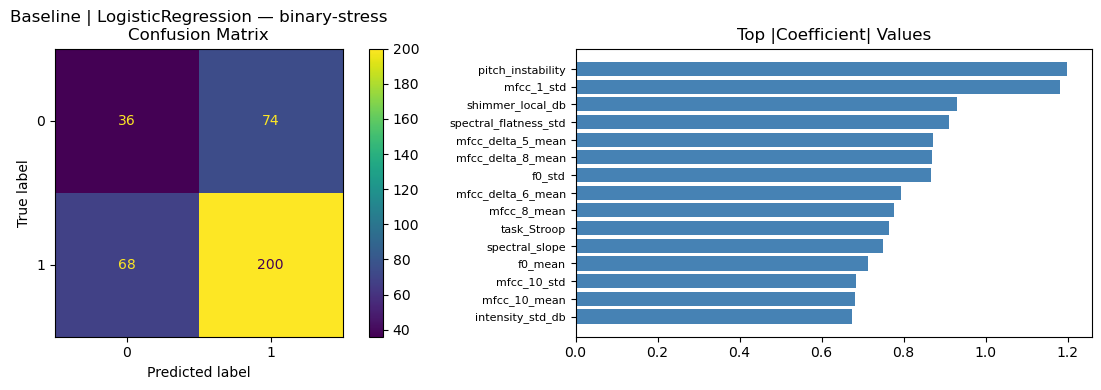


─── Baseline | LogisticRegression | target: affect3-class ───
  Accuracy: 0.421  |  Weighted F1: 0.420
              precision    recall  f1-score   support

           0       0.35      0.41      0.38        64
           1       0.29      0.27      0.28       124
           2       0.53      0.52      0.52       190

    accuracy                           0.42       378
   macro avg       0.39      0.40      0.39       378
weighted avg       0.42      0.42      0.42       378



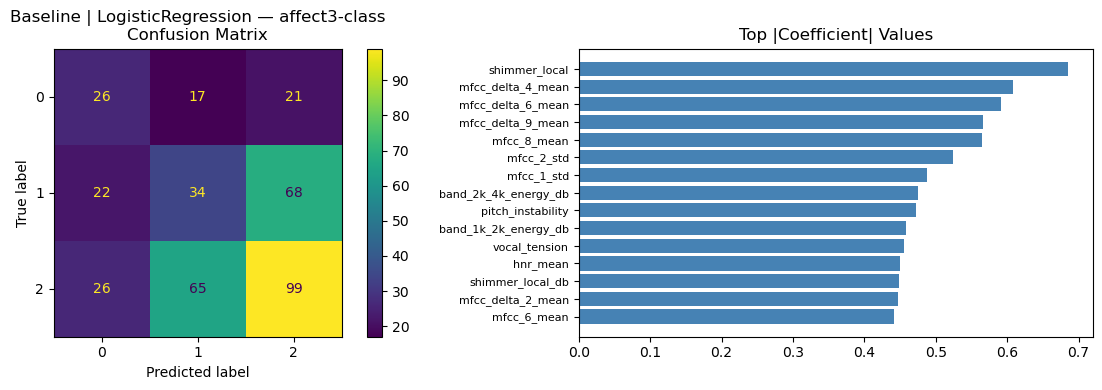


─── Baseline | RandomForest | target: binary-stress ───
  Accuracy: 0.704  |  Weighted F1: 0.632
              precision    recall  f1-score   support

           0       0.46      0.11      0.18       110
           1       0.72      0.95      0.82       268

    accuracy                           0.70       378
   macro avg       0.59      0.53      0.50       378
weighted avg       0.65      0.70      0.63       378



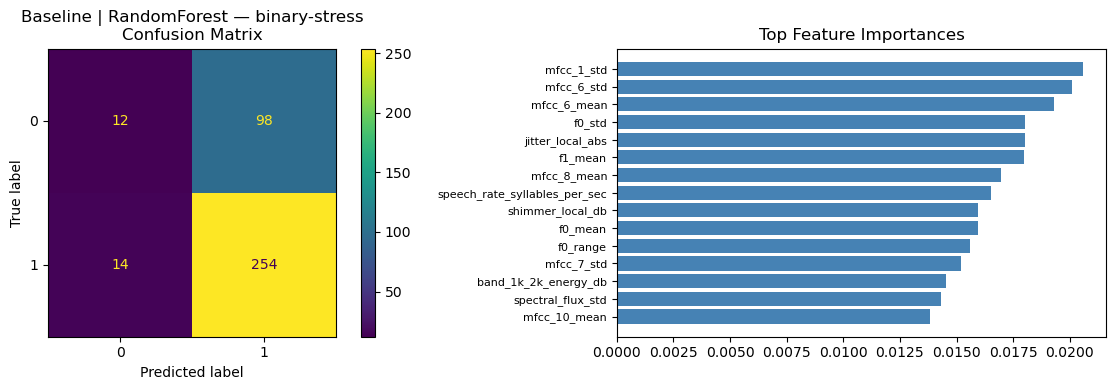


─── Baseline | RandomForest | target: affect3-class ───
  Accuracy: 0.495  |  Weighted F1: 0.443
              precision    recall  f1-score   support

           0       0.36      0.06      0.11        64
           1       0.38      0.27      0.32       124
           2       0.54      0.78      0.64       190

    accuracy                           0.49       378
   macro avg       0.43      0.37      0.35       378
weighted avg       0.46      0.49      0.44       378



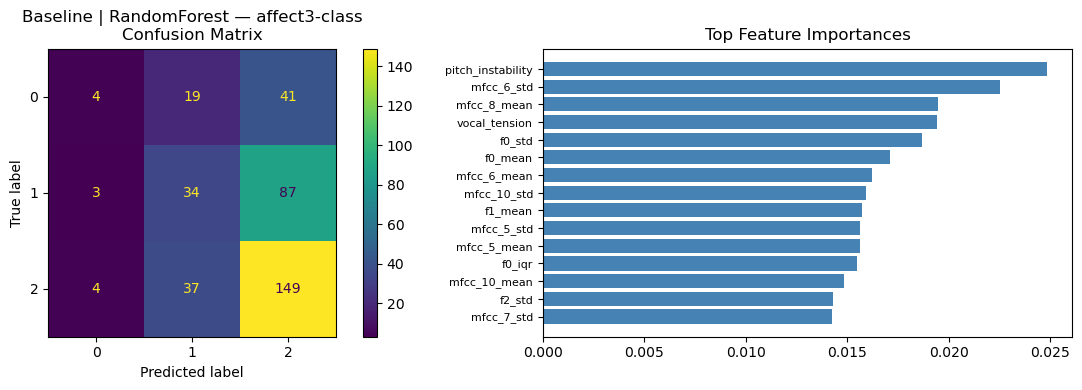

In [11]:
for mname, model in models.items():
    for target, y in [('binary-stress', y_binary), ('affect3-class', y_affect3)]:
        r = evaluate_classifier(X_acoustic, y, groups,
                                label_name=target,
                                model_name=f'Baseline | {mname}',
                                model=model,
                                feature_names=acoustic_feature_names)
        r['input'] = 'acoustic_direct'
        results.append(r)

## 5. Results Summary

In [12]:
results_df = pd.DataFrame(results)
pivot = results_df.pivot_table(
    index=['input', 'model'],
    columns='target',
    values=['accuracy', 'f1_weighted']
).round(3)
print(pivot.to_string())

                                                            accuracy                 f1_weighted              
target                                                 affect3-class binary-stress affect3-class binary-stress
input            model                                                                                        
acoustic_direct  Baseline | DecisionTree (max_depth=4)         0.468         0.622         0.441         0.604
                 Baseline | LogisticRegression                 0.421         0.624         0.420         0.621
                 Baseline | RandomForest                       0.495         0.704         0.443         0.632
oracle_physio    Oracle | DecisionTree (max_depth=4)           0.294         0.598         0.296         0.580
                 Oracle | LogisticRegression                   0.392         0.664         0.352         0.581
                 Oracle | RandomForest                         0.418         0.632         0.387         0.578
p

## 6. Decision Tree Visualisation (Interpretable Stage B)

A depth-4 Decision Tree trained on predicted physio features is fully interpretable — we can trace exactly which physiological signals drive the stress prediction.

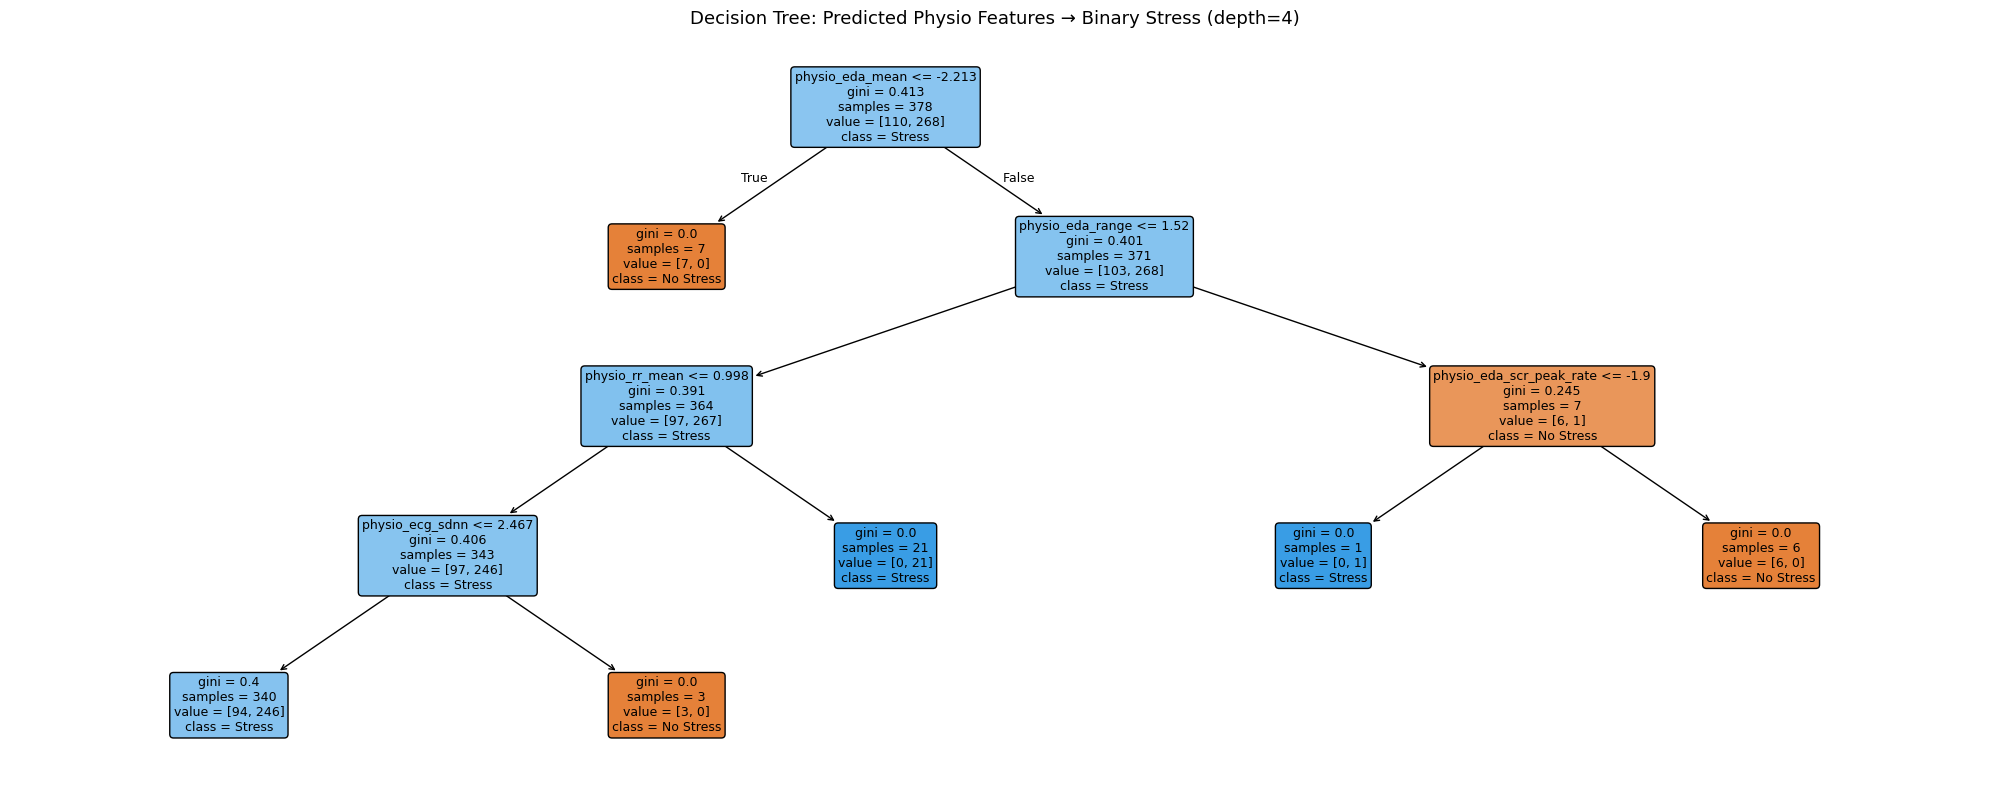

In [13]:
# Train final Decision Tree on full dataset (predicted physio → binary stress)
final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    DecisionTreeClassifier(max_depth=4, random_state=SEED))
])
final_pipe.fit(X_physio_pred, y_binary)
tree_clf = final_pipe.named_steps['clf']

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    tree_clf,
    feature_names=PHYSIO_COLS_VALID,
    class_names=['No Stress', 'Stress'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree: Predicted Physio Features → Binary Stress (depth=4)', fontsize=13)
plt.tight_layout()
plt.savefig('stageB_decision_tree.png', dpi=150)
plt.show()

## 7. Export Model 2 Outputs for Model 3

Save the cross-validated stress predictions alongside subject/task IDs for use in the ensemble aggregator (Model 3).

In [14]:
# Best Stage B: RandomForest on predicted physio (or acoustic direct — use whichever scored higher)
# We generate out-of-fold probability predictions for Model 3

best_model = RandomForestClassifier(n_estimators=100, random_state=SEED)
best_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     best_model)
])

# Out-of-fold probabilities
binary_probs = np.zeros((len(y_binary), 2))
affect3_probs = np.zeros((len(y_affect3), 3))

for train_idx, test_idx in gkf.split(X_physio_pred, y_binary, groups):
    # Binary stress
    best_pipe.fit(X_physio_pred[train_idx], y_binary[train_idx])
    binary_probs[test_idx] = best_pipe.predict_proba(X_physio_pred[test_idx])

    # Affect3
    best_pipe.fit(X_physio_pred[train_idx], y_affect3[train_idx])
    affect3_probs[test_idx] = best_pipe.predict_proba(X_physio_pred[test_idx])

model2_output = pd.DataFrame({
    'subject_id':              df['subject_id'].values,
    'task':                    df['task'].values,
    'binary_stress_true':      y_binary,
    'affect3_true':            y_affect3,
    'stress_prob_0':           binary_probs[:, 0],
    'stress_prob_1':           binary_probs[:, 1],
    'affect3_prob_low':        affect3_probs[:, 0],
    'affect3_prob_med':        affect3_probs[:, 1] if affect3_probs.shape[1] > 1 else np.nan,
    'affect3_prob_high':       affect3_probs[:, 2] if affect3_probs.shape[1] > 2 else np.nan,
    'stress_score':            binary_probs[:, 1],  # P(stress=1) as continuous score
})

out_path = 'data/stressid/features/model2_outputs.csv'
model2_output.to_csv(out_path, index=False)
print(f'Model 2 outputs saved to {out_path}')
print(model2_output.head())

Model 2 outputs saved to data/stressid/features/model2_outputs.csv
  subject_id       task  binary_stress_true  affect3_true  stress_prob_0  \
0       2ea4  Counting2                   1             2           0.29   
1       2ea4  Counting1                   1             2           0.11   
2       2ea4       Math                   1             2           0.34   
3       2ea4  Counting3                   1             2           0.20   
4       2ea4     Stroop                   0             0           0.16   

   stress_prob_1  affect3_prob_low  affect3_prob_med  affect3_prob_high  \
0           0.71              0.17              0.48               0.35   
1           0.89              0.24              0.28               0.48   
2           0.66              0.08              0.46               0.46   
3           0.80              0.10              0.16               0.74   
4           0.84              0.07              0.31               0.62   

   stress_score  
0      

In [15]:
# Subject-level aggregation: average stress_score across tasks per subject
subject_stress = (
    model2_output
    .groupby('subject_id')
    .agg(
        stress_score_mean=('stress_score', 'mean'),
        stress_score_max=('stress_score', 'max'),
        stress_binary_majority=('binary_stress_true', lambda x: int(x.mean() >= 0.5))
    )
    .reset_index()
)

subject_stress_path = 'data/stressid/features/model2_subject_scores.csv'
subject_stress.to_csv(subject_stress_path, index=False)
print(f'Subject-level scores saved to {subject_stress_path}')
print(subject_stress.head())

Subject-level scores saved to data/stressid/features/model2_subject_scores.csv
  subject_id  stress_score_mean  stress_score_max  stress_binary_majority
0       2ea4           0.725714              0.89                       1
1       2hpu           0.654286              0.76                       1
2       2z7d           0.668571              0.81                       1
3       45lx           0.847143              0.89                       1
4       4e8r           0.817143              0.88                       0
